In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("TensorFlow:", tf.__version__)


2026-05-22 17:36:05.365477: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779471365.577083      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779471365.641536      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779471366.174511      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779471366.174555      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779471366.174558      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


In [2]:
import numpy as np

x_train = np.load('/kaggle/input/notebooks/artikasaride/ds-may-22/split_data/x_train.npy')
x_val   = np.load('/kaggle/input/notebooks/artikasaride/ds-may-22/split_data/x_val.npy')
x_test  = np.load('/kaggle/input/notebooks/artikasaride/ds-may-22/split_data/x_test.npy')

y_train = np.load('/kaggle/input/notebooks/artikasaride/ds-may-22/split_data/y_train.npy')
y_val   = np.load('/kaggle/input/notebooks/artikasaride/ds-may-22/split_data/y_val.npy')
y_test  = np.load('/kaggle/input/notebooks/artikasaride/ds-may-22/split_data/y_test.npy')

In [3]:
print("Train :", x_train.shape, y_train.shape)
print("Val   :", x_val.shape, y_val.shape)
print("Test  :", x_test.shape, y_test.shape)

Train : (2801, 96, 96, 1) (2801,)
Val   : (599, 96, 96, 1) (599,)
Test  : (600, 96, 96, 1) (600,)


In [4]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)

inputs = Input(shape=(96, 96, 1), name="eye_input")

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid', name="eye_state")(x)
model   = Model(inputs, outputs, name="EyeStateClassifier")
model.summary()


I0000 00:00:1779471396.127145      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779471396.133299      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "EyeStateClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eye_input (InputLayer)          │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ eye_state (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,813,697 (18.36 MB)

 Trainable params: 4,812,737 (18.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [5]:
# ─── Custom Loss Function: Weighted Binary Crossentropy ───────────────────
# Mengatasi class imbalance — kelas minoritas (misal Closed) diberi bobot lebih tinggi

class WeightedBinaryCrossentropy(tf.keras.losses.Loss):
    """
    Custom Loss: Binary Crossentropy dengan pembobotan per kelas.
    Mengatasi dataset tidak seimbang antara Open dan Closed.
    """
    def __init__(self, class_weight: dict, name="weighted_bce"):
        super().__init__(name=name)
        self.w0 = tf.constant(class_weight[0], dtype=tf.float32)  # bobot Closed
        self.w1 = tf.constant(class_weight[1], dtype=tf.float32)  # bobot Open

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1, 1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1, 1]), tf.float32)

        bce     = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        weights = tf.where(tf.equal(y_true, 1.0), self.w1, self.w0)
        weights = tf.reshape(weights, tf.shape(bce))
        return tf.reduce_mean(bce * weights)


# ─── Custom Callback: Logger per epoch ────────────────────────────────────
class CustomLogger(tf.keras.callbacks.Callback):
    """Custom Callback: cetak ringkasan metrik tiap akhir epoch."""
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        print(
            f"  Epoch {epoch+1:3d} | "
            f"Loss: {logs.get('loss', 0):.4f} | "
            f"Acc: {logs.get('accuracy', 0)*100:.2f}% | "
            f"Val Loss: {logs.get('val_loss', 0):.4f} | "
            f"Val Acc: {logs.get('val_accuracy', 0)*100:.2f}%"
        )


In [6]:
# ── Class weights (fix class imbalance) ──────────────────────────────────
cw_arr  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {0: float(cw_arr[0]), 1: float(cw_arr[1])}
print(f"Class weights → Closed: {cw_dict[0]:.3f} | Open: {cw_dict[1]:.3f}")

# ── Loss & Optimizer ──────────────────────────────────────────────────────
loss_fn   = WeightedBinaryCrossentropy(cw_dict)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
logger    = CustomLogger()

# ── TensorBoard writers ───────────────────────────────────────────────────
# Side Quest — TensorBoard
log_dir = "/kaggle/working/logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
train_writer = tf.summary.create_file_writer(
    log_dir + "/train"
)

val_writer = tf.summary.create_file_writer(
    log_dir + "/val"
)

print(f"TensorBoard log dir: {log_dir}")

# ── Metrics ───────────────────────────────────────────────────────────────
t_loss_m = tf.keras.metrics.Mean()
t_acc_m  = tf.keras.metrics.BinaryAccuracy()
t_mae_m  = tf.keras.metrics.MeanAbsoluteError()
v_loss_m = tf.keras.metrics.Mean()
v_acc_m  = tf.keras.metrics.BinaryAccuracy()
v_mae_m  = tf.keras.metrics.MeanAbsoluteError()

# ── tf.data pipeline ──────────────────────────────────────────────────────
BATCH_SIZE = 32
EPOCHS     = 60

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(len(x_train), reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ── Augmentasi (in-graph, cepat) ─────────────────────────────────────────
@tf.function
def augment(imgs):
    imgs = tf.image.random_flip_left_right(imgs)
    imgs = tf.image.random_brightness(imgs, max_delta=0.1)
    imgs = tf.image.random_contrast(imgs, 0.9, 1.1)
    imgs = tf.clip_by_value(imgs, 0.0, 1.0)
    return imgs

# ── Train step (tf.function untuk kecepatan) ─────────────────────────────
@tf.function
def train_step(x_batch, y_batch):
    x_aug = augment(x_batch)
    with tf.GradientTape() as tape:
        preds = model(x_aug, training=True)
        loss  = loss_fn(y_batch, preds)
    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    return loss, preds

@tf.function
def val_step(x_batch, y_batch):
    preds = model(x_batch, training=False)
    loss  = loss_fn(y_batch, preds)
    return loss, preds

# ── Early Stopping & LR Reduction state ──────────────────────────────────
PATIENCE    = 7
LR_PATIENCE = 3
LR_FACTOR   = 0.5
MIN_LR      = 1e-6

best_val_loss = float('inf')
best_weights  = None
es_counter    = 0
lr_counter    = 0

# ═════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("  MULAI TRAINING — tf.GradientTape")
print("=" * 60)

for epoch in range(EPOCHS):

    # TRAIN ────────────────────────────────────────────────────────────
    for x_b, y_b in train_ds:
        loss, preds = train_step(x_b, y_b)
        t_loss_m.update_state(loss)
        t_acc_m.update_state(y_b, preds)
        t_mae_m.update_state(y_b, preds)

    # VALIDATION ───────────────────────────────────────────────────────
    for x_v, y_v in val_ds:
        v_loss, v_preds = val_step(x_v, y_v)
        v_loss_m.update_state(v_loss)
        v_acc_m.update_state(y_v, v_preds)
        v_mae_m.update_state(y_v, v_preds)

    t_loss = t_loss_m.result().numpy()
    t_acc  = t_acc_m.result().numpy()
    t_mae  = t_mae_m.result().numpy()
    v_loss = v_loss_m.result().numpy()
    v_acc  = v_acc_m.result().numpy()
    v_mae  = v_mae_m.result().numpy()
    cur_lr = float(optimizer.learning_rate)

    # TensorBoard logging ──────────────────────────────────────────────
    with train_writer.as_default():
        tf.summary.scalar('loss',     t_loss, step=epoch)
        tf.summary.scalar('accuracy', t_acc,  step=epoch)
        tf.summary.scalar('mae',      t_mae,  step=epoch)
        tf.summary.scalar('lr',       cur_lr, step=epoch)
    with val_writer.as_default():
        tf.summary.scalar('loss',     v_loss, step=epoch)
        tf.summary.scalar('accuracy', v_acc,  step=epoch)
        tf.summary.scalar('mae',      v_mae,  step=epoch)

    # CustomLogger ─────────────────────────────────────────────────────
    logger.on_epoch_end(epoch, {
        'loss': t_loss, 'accuracy': t_acc,
        'val_loss': v_loss, 'val_accuracy': v_acc
    })

    # Reset metrics ────────────────────────────────────────────────────
    for m in [t_loss_m, t_acc_m, t_mae_m, v_loss_m, v_acc_m, v_mae_m]:
        m.reset_state()

    # ─── Early Stopping & LR Reduction ───────────────────────────────
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_weights  = model.get_weights()
        es_counter    = 0
        lr_counter    = 0
    else:
        es_counter += 1
        lr_counter += 1

    if lr_counter >= LR_PATIENCE:
        new_lr = max(cur_lr * LR_FACTOR, MIN_LR)
        optimizer.learning_rate.assign(new_lr)
        lr_counter = 0
        print(f"    ↓ Learning rate dikurangi → {new_lr:.2e}")

    if es_counter >= PATIENCE:
        print(f"\n⏹ Early stopping pada epoch {epoch+1} (val_loss tidak membaik)")
        break

# Pulihkan bobot terbaik
if best_weights:
    model.set_weights(best_weights)
    print("\n✅ Best weights dipulihkan.")

print("=" * 60)
print("  TRAINING SELESAI")
print(f"  Best val_loss : {best_val_loss:.4f}")
print("=" * 60)


Class weights → Closed: 1.000 | Open: 1.000
TensorBoard log dir: /kaggle/working/logs/fit/20260522-173637
  MULAI TRAINING — tf.GradientTape


I0000 00:00:1779471402.230851      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


  Epoch   1 | Loss: 0.0949 | Acc: 96.68% | Val Loss: 3.6851 | Val Acc: 50.08%
  Epoch   2 | Loss: 0.0274 | Acc: 99.04% | Val Loss: 4.3889 | Val Acc: 50.08%
  Epoch   3 | Loss: 0.0105 | Acc: 99.75% | Val Loss: 3.0041 | Val Acc: 50.08%
  Epoch   4 | Loss: 0.0168 | Acc: 99.39% | Val Loss: 1.4712 | Val Acc: 62.77%
  Epoch   5 | Loss: 0.0048 | Acc: 99.93% | Val Loss: 0.9397 | Val Acc: 71.79%
  Epoch   6 | Loss: 0.0020 | Acc: 100.00% | Val Loss: 0.1270 | Val Acc: 93.82%
  Epoch   7 | Loss: 0.0073 | Acc: 99.79% | Val Loss: 0.0978 | Val Acc: 95.66%
  Epoch   8 | Loss: 0.0056 | Acc: 99.86% | Val Loss: 0.0095 | Val Acc: 99.83%
  Epoch   9 | Loss: 0.0021 | Acc: 99.93% | Val Loss: 0.0016 | Val Acc: 100.00%
  Epoch  10 | Loss: 0.0015 | Acc: 99.96% | Val Loss: 0.0026 | Val Acc: 99.83%
  Epoch  11 | Loss: 0.0006 | Acc: 100.00% | Val Loss: 0.0009 | Val Acc: 100.00%
  Epoch  12 | Loss: 0.0005 | Acc: 100.00% | Val Loss: 0.0006 | Val Acc: 100.00%
  Epoch  13 | Loss: 0.0007 | Acc: 100.00% | Val Loss: 0.00

In [7]:
def evaluate_split(name, x, y):

    preds = model.predict(
        x,
        batch_size=32,
        verbose=0
    ).flatten()

    labels_pred = (
        preds > 0.5
    ).astype(int)

    acc = np.mean(
        labels_pred == y
    )

    mae = np.mean(
        np.abs(
            preds - y
        )
    )

    bce = tf.keras.losses.BinaryCrossentropy()(
        y.astype(np.float32),
        preds
    ).numpy()

    print(
        f"{name:<12} | "
        f"Loss: {bce:.4f} | "
        f"Accuracy: {acc*100:.2f}% | "
        f"MAE: {mae:.4f}"
    )

    return acc, mae


print("=" * 55)
print("          HASIL EVALUASI")
print("=" * 55)

evaluate_split(
    "Train",
    x_train,
    y_train
)

evaluate_split(
    "Validation",
    x_val,
    y_val
)

t_acc, t_mae = evaluate_split(
    "Test",
    x_test,
    y_test
)

print("=" * 55)

acc_ok = (
    t_acc >= 0.85
)

mae_ok = (
    t_mae <= 0.02
)

print(
    f"\nAkurasi >=85% : {'LULUS' if acc_ok else 'BELUM'}"
)

print(
    f"MAE <=0.02 : {'LULUS' if mae_ok else 'BELUM'}"
)


          HASIL EVALUASI


I0000 00:00:1779471458.473005      71 service.cc:152] XLA service 0x7c7367acae30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779471458.473040      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779471458.473043      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779471459.282658      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Train        | Loss: 0.0001 | Accuracy: 100.00% | MAE: 0.0001
Validation   | Loss: 0.0006 | Accuracy: 100.00% | MAE: 0.0005
Test         | Loss: 0.0002 | Accuracy: 100.00% | MAE: 0.0002

Akurasi >=85% : LULUS
MAE <=0.02 : LULUS


In [8]:
from sklearn.metrics import confusion_matrix

preds = model.predict(x_test)
pred_labels = (preds > 0.5).astype(int)

cm = confusion_matrix(
    y_test,
    pred_labels
)

print(cm)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[300   0]
 [  0 300]]


In [9]:
# ── Metrics ────────────────────────────────────────────────────────
precision = precision_score(
    y_test,
    pred_labels
)

recall = recall_score(
    y_test,
    pred_labels
)

f1 = f1_score(
    y_test,
    pred_labels
)

print("\n" + "=" * 55)
print("          METRICS TEST SET")
print("=" * 55)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")



          METRICS TEST SET
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


In [10]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc
)

In [11]:
roc_auc = roc_auc_score(
    y_test,
    preds
)

print(f"\nROC-AUC Score : {roc_auc:.4f}")


ROC-AUC Score : 1.0000


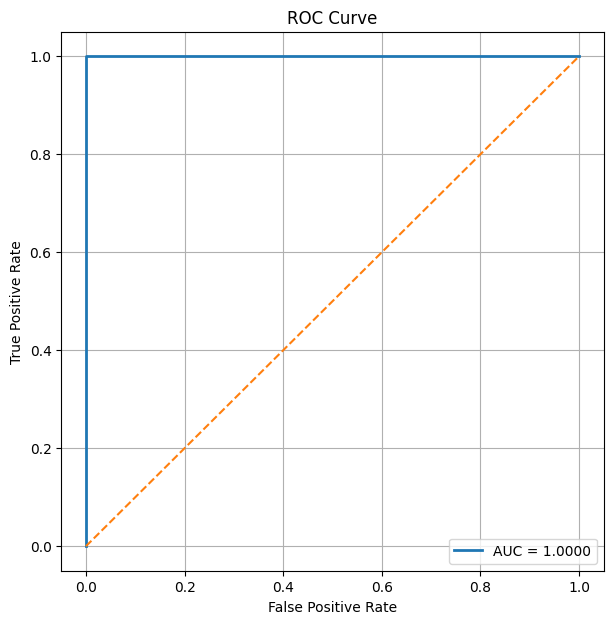

In [12]:
import matplotlib.pyplot as plt

# ── ROC Curve ───────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(
    y_test,
    preds
)

roc_auc = auc(
    fpr,
    tpr
)

# ── Plot ────────────────────────────────────────────────────
plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.grid(True)

plt.show()

In [13]:
model.save("/kaggle/working/eye_model_22mei.keras")

print("✅ Model disimpan: eye_model_22mei.keras")

✅ Model disimpan: eye_model_22mei.keras


In [14]:
import shutil

shutil.make_archive(
    "/kaggle/working/logs_backup",
    "zip",
    "/kaggle/working/logs"
)

print("✅ Berhasil dibuat: logs_backup.zip")

✅ Berhasil dibuat: logs_backup.zip


In [15]:
# FIX: gunakan (96,96) sesuai input shape model, bukan (64,64)
def predict_image(img_path, model, threshold=0.5):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return "Error: gambar tidak ditemukan"
    img = cv2.resize(img, (96, 96)) / 255.0
    img = np.expand_dims(img, axis=(0, -1))
    score = float(model.predict(img, verbose=0)[0][0])
    label = "Open" if score > threshold else "Closed"
    return label, score


def show_prediction(img_path, model):
    result, score = predict_image(img_path, model)
    print(f"Prediction: {result} (score: {score:.4f})")
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Prediction: {result} ({score:.2f})", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [16]:
def show_prediction(img_path, model):
    result, score = predict_image(img_path, model)
    print(f"Prediction: {result} (score: {score:.4f})")
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Prediction: {result} ({score:.2f})", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Prediction: Closed (score: 0.0001)


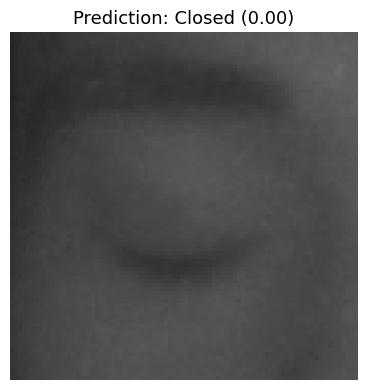

In [17]:
show_prediction("/kaggle/input/datasets/prasadvpatil/mrl-dataset/train/Closed_Eyes/s0001_00001_0_0_0_0_0_01.png", model)


Prediction: Open (score: 0.9976)


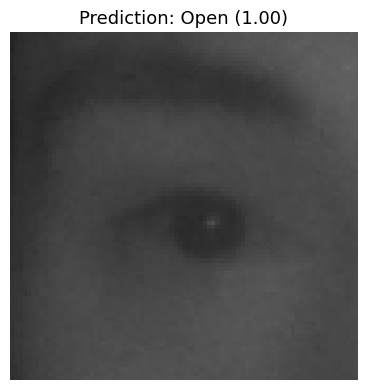

In [18]:
show_prediction("/kaggle/input/datasets/prasadvpatil/mrl-dataset/train/Open_Eyes/s0001_02334_0_0_1_0_0_01.png", model)


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_with_box(img_path, model, threshold=0.5):

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faceCascade = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        "haarcascade_frontalface_default.xml"
    )

    eyeCascade = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        "haarcascade_eye.xml"
    )

    faces = faceCascade.detectMultiScale(
        gray,
        1.1,
        4
    )

    for (x,y,w,h) in faces:

        roi_gray = gray[
            y:y+h,
            x:x+w
        ]

        roi_color = img_rgb[
            y:y+h,
            x:x+w
        ]

        eyes = eyeCascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.1,
            minNeighbors=8,
            minSize=(30,30)
        )

        # ambil maksimal 2 mata
        eyes = sorted(
            eyes,
            key=lambda e:e[2]*e[3],
            reverse=True
        )[:2]

        for (ex,ey,ew,eh) in eyes:

            eye_roi = roi_gray[
                ey:ey+eh,
                ex:ex+ew
            ]

            eye = cv2.resize(
                eye_roi,
                (96,96)
            )/255.0

            eye=np.expand_dims(
                eye,
                axis=(0,-1)
            )

            score=float(
                model.predict(
                    eye,
                    verbose=0
                )[0][0]
            )

            label=(
                "Open"
                if score>0.5
                else "Closed"
            )

            conf=max(
                score,
                1-score
            )

            color=(0,255,0) if label=="Open" else (255,0,0)

            cv2.rectangle(
                roi_color,
                (ex,ey),
                (ex+ew,ey+eh),
                color,
                2
            )

            cv2.putText(
                roi_color,
                f"{label} ({conf:.2f})",
                (ex,ey-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                2
            )

    plt.figure(figsize=(8,8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

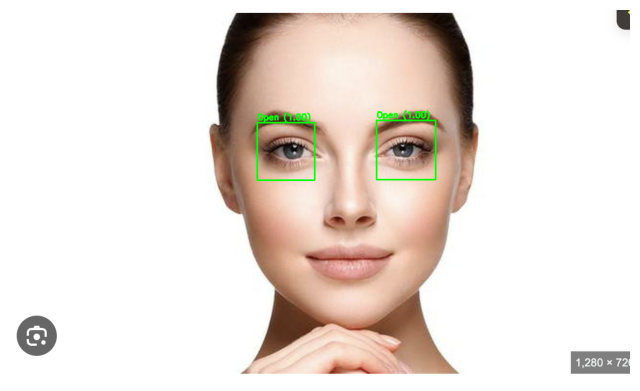

In [20]:
predict_with_box(
    "/kaggle/input/datasets/rifkaalyadamayantii/tesssss/Screenshot 2026-05-22 at 00.15.13.png",
    model
)